## 1. Setup and Load Data

In [1]:
import sys
sys.path.append(r"D:\Quant\Multi_factor_project")
from config import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False

factor_panel = pd.read_parquet(f"{DATA_CLEAN}/factor_panel.parquet")

hs300 = pd.read_parquet(f"{DATA_RAW}/daily/hs300_index.parquet")
hs300['trade_date'] = pd.to_datetime(hs300['trade_date'])

print(f"OK factor_panel: {factor_panel.shape}")
print(f"OK hs300: {hs300.shape}")

✓ factor_panel: (35255, 19)
✓ hs300: (2431, 11)


## 2. Top-N Stock Selection

Rank stocks by composite factor score within each month and select the top N.

In [2]:
def select_top_n(factor_panel, score_col='composite', top_n=30):
    \"\"\"
    Rank stocks by composite factor score each month and select the Top N.
    \"\"\"
    df = factor_panel.dropna(subset=[score_col]).copy()
    df['rank'] = df.groupby('month')[score_col].rank(ascending=False)
    selected = df[df['rank'] <= top_n].copy()
    print(f"Stock selection complete, Top{top_n}")
    print(f"Average number of stocks selected per month: {selected.groupby('month').size().mean():.1f}")
    
    return selected

selected_stocks = select_top_n(factor_panel, score_col='composite', top_n=30)
selected_stocks[['month','ts_code','composite','ret_1m']].head(10)

选股完成，Top30
每月平均选中股票数：30.0


,month,ts_code,composite,ret_1m
130,2016-07-01,000002.SZ,0.749689,-0.269034
132,2016-09-01,000002.SZ,1.166616,0.049739
133,2016-10-01,000002.SZ,1.096881,-0.047765
134,2016-11-01,000002.SZ,1.142288,0.082665
135,2016-12-01,000002.SZ,1.349296,-0.238325
136,2017-01-01,000002.SZ,1.354589,0.006326
137,2017-02-01,000002.SZ,1.341032,-0.007253
138,2017-03-01,000002.SZ,1.125635,0.002435
139,2017-04-01,000002.SZ,0.988868,-0.052478
140,2017-05-01,000002.SZ,1.104685,0.090256


## 3. Portfolio Return Calculation

Compute the equal-weighted gross monthly return of the selected portfolio, reusing the same non-consecutive-month gap guard from Chapter 04. **Note:** the returned series is indexed by the *selection* month T, but its value is the realized return of the *following* month (see review notes below the notebook on how this is reconciled downstream).

In [3]:
def calc_portfolio_return(selected_stocks):
    \"\"\"
    Equal-weight the Top N holdings and return the portfolio's gross monthly return
    (indexed by the stock-selection month T).
    Includes the Bug1 fix: for a stock that drops out of and re-enters the universe,
    the next row is not necessarily the following calendar month -> the return is voided.
    \"\"\"
    df = factor_panel.copy()
    df = df.sort_values(['ts_code','month'])
    df['next_ret']   = df.groupby('ts_code')['ret_1m'].shift(-1)
    df['next_month'] = df.groupby('ts_code')['month'].shift(-1)

    gap = (df['next_month'].dt.to_period('M') - df['month'].dt.to_period('M')
           ).apply(lambda x: x.n if pd.notna(x) else np.nan)
    df.loc[gap != 1, 'next_ret'] = np.nan

    # Safeguard: drop any leftover same-named columns from `selected`, to avoid merge suffix collisions (_x/_y)
    clean_sel = selected_stocks.drop(
        columns=[c for c in ['next_ret','next_month'] if c in selected_stocks.columns])
    merged = clean_sel.merge(df[['ts_code','month','next_ret']],
                             on=['ts_code','month'], how='left')

    portfolio_ret = merged.groupby('month')['next_ret'].mean().dropna()
    return portfolio_ret

portfolio_ret = calc_portfolio_return(selected_stocks)

## 4. Net Return, Turnover, and Benchmark Return

Deduct estimated turnover cost from the gross return, and compute the CSI 300 benchmark's monthly return for comparison.

In [14]:
def calc_net_return(selected_stocks, cost=0.0025):
    \"\"\"Gross return minus turnover cost. Returns: (net return series, average monthly turnover)\"\"\"
    holdings = selected_stocks.groupby('month')['ts_code'].apply(set)
    months = sorted(holdings.index)
    turnover = pd.Series({
        cur: len(holdings[cur] - holdings[prev]) / len(holdings[cur])
        for prev, cur in zip(months[:-1], months[1:])
    })
    gross = calc_portfolio_return(selected_stocks)
    net = gross - (turnover * cost).reindex(gross.index).fillna(0)
    avg_turnover = turnover.reindex(gross.index).mean()
    return net, avg_turnover
portfolio_ret_net, avg_to = calc_net_return(selected_stocks)
print(f"Average monthly turnover: {avg_to*100:.1f}%")
print(f"Approximate annual cost drag: {avg_to*0.0025*12*100:.1f}%")
def calc_benchmark_return(hs300):
    \"\"\"CSI 300 monthly return\"\"\"
    df = hs300.copy()
    df['month'] = df['trade_date'].dt.to_period('M').dt.to_timestamp()
    
    monthly_close = df.groupby('month')['close'].last()
    benchmark_ret = monthly_close.pct_change().dropna()
    
    print(f"Benchmark monthly return calculation complete: {len(benchmark_ret)} months")
    return benchmark_ret

benchmark_ret = calc_benchmark_return(hs300)

平均月换手率：26.5%
年均成本损耗：约 0.8%
基准月度收益计算完成：119个月


## 5. Portfolio vs. Benchmark NAV Comparison

Align the portfolio return series to the calendar month in which it was actually realized (offsetting the index by one month), then compare cumulative NAV and headline performance metrics against the CSI 300 benchmark.

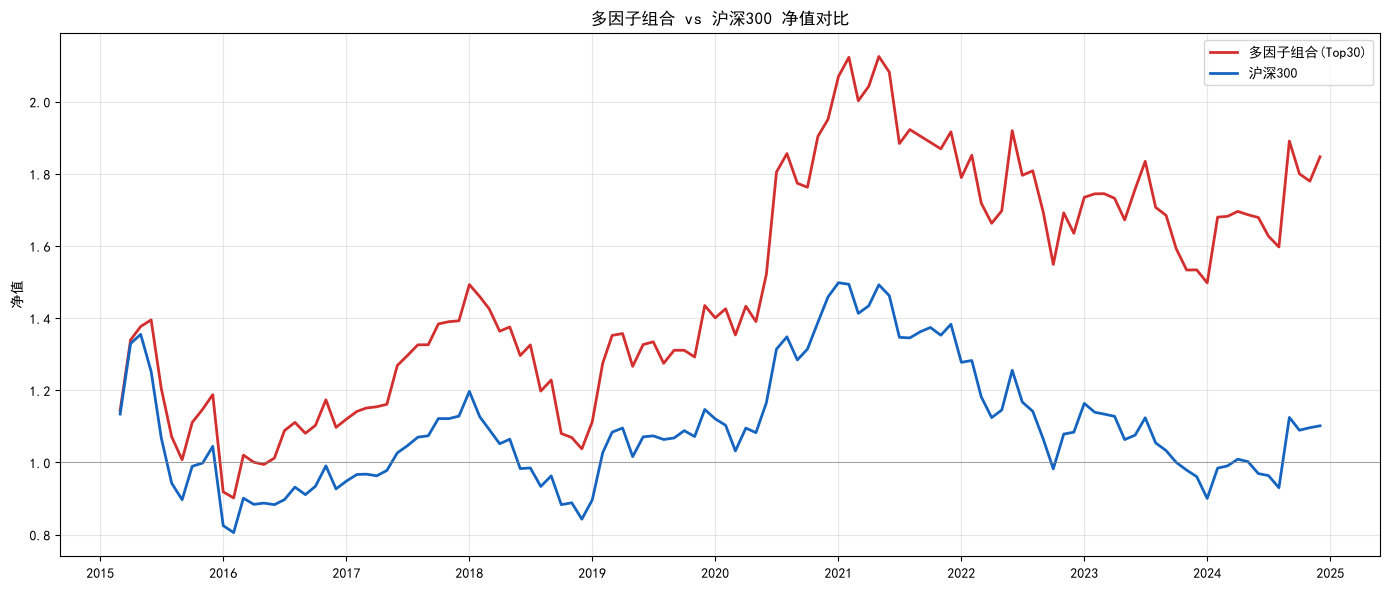

年化超额：5.56%
信息比率：0.77
月度胜率：54.2%
指标                 多因子组合       沪深300
年化收益               6.44%       0.99%
年化波动              22.40%      21.05%
夏普比率                0.29        0.05
最大回撤             -35.38%     -40.56%


In [15]:
def plot_portfolio_vs_benchmark(portfolio_ret, benchmark_ret):
    \"\"\"Portfolio vs. CSI 300 NAV comparison\"\"\"
    portfolio_ret = portfolio_ret.copy()
    portfolio_ret.index = portfolio_ret.index + pd.offsets.MonthBegin(1)  # <- offset moved into the function
    
    # Align the time ranges
    common_idx = portfolio_ret.index.intersection(benchmark_ret.index)
    p_ret = portfolio_ret.loc[common_idx]
    b_ret = benchmark_ret.loc[common_idx]
    
    p_nav = (1 + p_ret).cumprod()
    b_nav = (1 + b_ret).cumprod()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(p_nav.index, p_nav.values, label='Multi-Factor Portfolio (Top30)', linewidth=2, color='#D32F2F')
    ax.plot(b_nav.index, b_nav.values, label='CSI 300', linewidth=2, color='#1565C0')
    ax.axhline(1, color='gray', linewidth=0.5)
    ax.set_title('Multi-Factor Portfolio vs. CSI 300 NAV Comparison')
    ax.set_ylabel('NAV')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/plots/portfolio_vs_benchmark.png", dpi=150)
    plt.show()
    
    # Key performance metrics
    ann_ret_p = (p_nav.iloc[-1]) ** (12/len(p_ret)) - 1
    ann_ret_b = (b_nav.iloc[-1]) ** (12/len(b_ret)) - 1
    ann_vol_p = p_ret.std() * np.sqrt(12)
    ann_vol_b = b_ret.std() * np.sqrt(12)
    sharpe_p = ann_ret_p / ann_vol_p
    sharpe_b = ann_ret_b / ann_vol_b
    
    max_dd_p = ((p_nav / p_nav.cummax()) - 1).min()
    max_dd_b = ((b_nav / b_nav.cummax()) - 1).min()

    excess = p_ret - b_ret
    print(f"Annualized excess return: {excess.mean()*12*100:.2f}%")
    print(f"Information ratio: {excess.mean()/excess.std()*np.sqrt(12):.2f}")   # >0.5 acceptable, >1 excellent
    print(f"Monthly win rate: {(excess>0).mean()*100:.1f}%")
    print(f"{'Metric':<14}{'Multi-Factor':>14}{'CSI 300':>14}")
    print(f"{'Ann. return':<14}{ann_ret_p*100:>13.2f}%{ann_ret_b*100:>13.2f}%")
    print(f"{'Ann. vol':<14}{ann_vol_p*100:>13.2f}%{ann_vol_b*100:>13.2f}%")
    print(f"{'Sharpe':<14}{sharpe_p:>14.2f}{sharpe_b:>14.2f}")
    print(f"{'Max drawdown':<14}{max_dd_p*100:>13.2f}%{max_dd_b*100:>13.2f}%")
    
    return p_nav, b_nav
p_nav, b_nav = plot_portfolio_vs_benchmark(portfolio_ret_net, benchmark_ret)

## 6. Alpha/Beta Regression

Regress the portfolio's net monthly return on the benchmark's return to estimate Alpha and Beta, with a manually computed standard error, t-statistic, and p-value for Alpha's significance.

In [17]:
def calc_alpha_beta(portfolio_ret, benchmark_ret):
    \"\"\"Regress portfolio return on benchmark return: R_p = alpha + beta * R_benchmark + epsilon\"\"\"
    portfolio_ret = portfolio_ret.copy()
    portfolio_ret.index = portfolio_ret.index + pd.offsets.MonthBegin(1)   # <- these two lines added
    common_idx = portfolio_ret.index.intersection(benchmark_ret.index)
    merged = pd.DataFrame({
        'portfolio': portfolio_ret.loc[common_idx],
        'benchmark': benchmark_ret.loc[common_idx]
    }).dropna()
    
    X = merged['benchmark'].values
    y = merged['portfolio'].values
    
    beta, alpha = np.polyfit(X, y, 1)
    
    y_pred = alpha + beta * X
    residuals = y - y_pred
    n = len(X)
    dof = n - 2
    
    mse = np.sum(residuals**2) / dof
    se_alpha = np.sqrt(mse * (1/n + np.mean(X)**2 / np.sum((X-np.mean(X))**2)))
    t_alpha = alpha / se_alpha
    p_alpha = 2 * (1 - stats.t.cdf(abs(t_alpha), dof))
    
    print(f"Regression results (monthly):")
    print(f"  Alpha: {alpha:.4f}  (annualized: {alpha*12*100:.2f}%)")
    print(f"  Beta: {beta:.4f}")
    print(f"  Alpha t-stat: {t_alpha:.2f}")
    print(f"  Alpha p-value: {p_alpha:.4f}")
    print(f"  {'OK Alpha is statistically significant (p<0.05)' if p_alpha < 0.05 else 'Alpha is not significant'}")
    
    return {'alpha': alpha, 'beta': beta, 't_alpha': t_alpha, 'p_alpha': p_alpha}

from scipy import stats
result = calc_alpha_beta(portfolio_ret_net, benchmark_ret)

回归结果（月度）：
  Alpha: 0.0046  (年化: 5.54%)
  Beta: 1.0070
  Alpha t值: 2.39
  Alpha p值: 0.0187
  ✓ Alpha统计显著（p<0.05）


## 7. Robustness Check: Segmented Sharpe/IR Sensitivity to Top-N

Sweep the portfolio size N and evaluate Sharpe ratio and Information Ratio within three sub-periods, to select N based on stability across market regimes rather than full-sample performance alone.

In [11]:
def sensitivity_topn_segmented(factor_panel, benchmark_ret,
                               n_list=[10,15,20,30,50,80,100],
                               cost=0.0025, n_segments=3):
    \"\"\"Split the backtest into 3 sub-periods and compute Sharpe and IR in each,
    using the excess-return basis for a robustness screen.\"\"\"
    rows = []
    for n in n_list:
        selected = select_top_n(factor_panel, score_col='composite', top_n=n)
        p_ret, avg_to = calc_net_return(selected, cost=cost)

        p_aligned = p_ret.copy()
        p_aligned.index = p_aligned.index + pd.DateOffset(months=1)
        common = p_aligned.index.intersection(benchmark_ret.index)
        p = p_aligned.loc[common]
        b = benchmark_ret.loc[common]

        seg_size = len(p) // n_segments
        seg_sharpes, seg_irs = [], []
        for s in range(n_segments):
            end = (s+1)*seg_size if s < n_segments-1 else len(p)
            seg_p = p.iloc[s*seg_size:end]
            seg_b = b.loc[seg_p.index]

            ar = (1+seg_p).prod()**(12/len(seg_p)) - 1
            seg_sharpes.append(ar / (seg_p.std() * np.sqrt(12)))

            ex = seg_p - seg_b                                   # segment excess return
            seg_irs.append(ex.mean() / ex.std() * np.sqrt(12))   # segment IR

        excess = p - b
        rows.append({
            'N': n,
            'sharpe_seg1': seg_sharpes[0], 'sharpe_seg2': seg_sharpes[1], 'sharpe_seg3': seg_sharpes[2],
            'ir_seg1': seg_irs[0], 'ir_seg2': seg_irs[1], 'ir_seg3': seg_irs[2],
            'ir_worst': np.min(seg_irs), 'ir_std': np.std(seg_irs),
            'ir_full': excess.mean()/excess.std()*np.sqrt(12),
            'avg_monthly_turnover': avg_to, 'annual_cost': avg_to*cost*12
        })
        print(f"N={n} complete")
    return pd.DataFrame(rows)

sens_df = sensitivity_topn_segmented(factor_panel, benchmark_ret)
print("\n" + sens_df.round(3).to_string(index=False))

选股完成，Top10
每月平均选中股票数：10.0
N=10 完成
选股完成，Top15
每月平均选中股票数：15.0
N=15 完成
选股完成，Top20
每月平均选中股票数：20.0
N=20 完成
选股完成，Top30
每月平均选中股票数：30.0
N=30 完成
选股完成，Top50
每月平均选中股票数：50.0
N=50 完成
选股完成，Top80
每月平均选中股票数：80.0
N=80 完成
选股完成，Top100
每月平均选中股票数：100.0
N=100 完成

  N  夏普_段1  夏普_段2  夏普_段3  IR_段1  IR_段2  IR_段3  IR_最差  IR_波动  IR_全程  月均换手   年成本
 10  0.490  0.399 -0.209  0.951  0.381  0.149  0.149  0.337  0.503 0.337 0.010
 15  0.414  0.489 -0.112  0.843  0.543  0.365  0.365  0.197  0.575 0.329 0.010
 20  0.410  0.645 -0.128  0.976  0.874  0.390  0.390  0.256  0.740 0.305 0.009
 30  0.410  0.486 -0.060  1.137  0.493  0.684  0.493  0.270  0.767 0.265 0.008
 50  0.404  0.573 -0.098  1.320  0.787  0.647  0.647  0.290  0.923 0.217 0.007
 80  0.331  0.578 -0.170  1.268  0.694  0.460  0.460  0.340  0.801 0.178 0.005
100  0.330  0.607 -0.110  1.364  1.003  0.769  0.769  0.245  1.050 0.159 0.005


## 8. Select Best N (Segmented IR Maximin Rule)

Among N values with a positive IR in every sub-period, choose the one that maximizes the worst-case segment IR, breaking ties by full-sample IR.

In [12]:
# Rule 1: IR positive in all three sub-periods (outperforms the benchmark in every regime)
cand = sens_df[(sens_df['ir_seg1']>0) & (sens_df['ir_seg2']>0) & (sens_df['ir_seg3']>0)]

# Rule 2: maximize the worst-segment IR; Rule 3: prefer higher full-sample IR as a tiebreaker
cand = cand.sort_values(['ir_worst','ir_full'], ascending=[False, False])

print("=== Candidate ranking (segmented IR maximin) ===")
print(cand[['N','ir_seg1','ir_seg2','ir_seg3','ir_worst','ir_full','avg_monthly_turnover','annual_cost']].round(3).to_string(index=False))

best_n = int(cand.iloc[0]['N'])
print(f"\nOK Selected N = {best_n}")

=== 候选排序（分段IR-Maximin）===
  N  IR_段1  IR_段2  IR_段3  IR_最差  IR_全程  月均换手   年成本
100  1.364  1.003  0.769  0.769  1.050 0.159 0.005
 50  1.320  0.787  0.647  0.647  0.923 0.217 0.007
 30  1.137  0.493  0.684  0.493  0.767 0.265 0.008
 80  1.268  0.694  0.460  0.460  0.801 0.178 0.005
 20  0.976  0.874  0.390  0.390  0.740 0.305 0.009
 15  0.843  0.543  0.365  0.365  0.575 0.329 0.010
 10  0.951  0.381  0.149  0.149  0.503 0.337 0.010

✓ 选定 N = 100


## 9. Industry-Neutral Variant: N Sweep

**Dependency note:** this cell calls `build_industry_neutral(...)` and references `universe_raw`, neither of which is defined or loaded earlier in this notebook — see review notes below for how to resolve this before a clean Restart & Run All.

In [22]:
# ===== Industry-neutral variant: N sweep and excess-return comparison =====
def perf_metrics(p_ret, benchmark_ret):
    \"\"\"Compute the full set of performance metrics for a single net-return series
    (index alignment is handled internally).\"\"\"
    p = p_ret.copy()
    p.index = p.index + pd.DateOffset(months=1)
    common = p.index.intersection(benchmark_ret.index)
    p, b = p.loc[common], benchmark_ret.loc[common]

    ann_ret = (1+p).prod()**(12/len(p)) - 1
    ann_vol = p.std() * np.sqrt(12)
    ex = p - b
    return {
        'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': ann_ret/ann_vol,
        'ann_excess': ex.mean()*12, 'tracking_error': ex.std()*np.sqrt(12),
        'ir': ex.mean()/ex.std()*np.sqrt(12),
        'monthly_win_rate': (ex>0).mean(),
        'max_drawdown': ((1+p).cumprod()/(1+p).cumprod().cummax()-1).min()
    }

n_list = [30, 50, 80, 100]
rows, net_store = [], {}

for n in n_list:
    picked = build_industry_neutral(factor_panel, universe_raw, n)
    net, to = calc_net_return(picked)
    net_store[n] = net                        # store for plotting after N is selected

    m = perf_metrics(net, benchmark_ret)
    m['N'] = n
    m['avg_monthly_turnover'] = to
    m['annual_cost'] = to * 0.0025 * 12
    rows.append(m)
    print(f"N={n} complete (avg. monthly holdings {picked.groupby('month').size().mean():.0f}, turnover {to*100:.1f}%)")

neutral_df = pd.DataFrame(rows).set_index('N')
print("\n=== Industry-Neutral: N Comparison Table (net of costs) ===")
print(neutral_df[['ann_excess','tracking_error','ir','sharpe','monthly_win_rate','max_drawdown','avg_monthly_turnover','annual_cost']].round(3))

月均持仓：29 只（目标≈30）
N=30 完成（月均持仓 29 只，换手 28.8%）
月均持仓：50 只（目标≈50）
N=50 完成（月均持仓 50 只，换手 23.7%）
月均持仓：80 只（目标≈80）
N=80 完成（月均持仓 80 只，换手 18.8%）
月均持仓：99 只（目标≈100）
N=100 完成（月均持仓 99 只，换手 15.4%）

=== 行业中性：N 对比表（扣费后）===
      年化超额   跟踪误差     IR     夏普    月胜率   最大回撤   月均换手    年成本
N                                                          
30   0.049  0.059  0.827  0.260  0.602 -0.365  0.288  0.009
50   0.052  0.049  1.050  0.287  0.653 -0.354  0.237  0.007
80   0.041  0.041  0.988  0.243  0.627 -0.357  0.188  0.006
100  0.042  0.038  1.099  0.244  0.610 -0.361  0.154  0.005


## 10. Final Industry-Neutral Strategy Selection and Comparison

Select the final N among industry-neutral candidates meeting an IR threshold, and plot the resulting strategy's NAV against the CSI 300 benchmark.

✓ 行业中性方案最终选定 N = 50
年化收益    0.062
年化波动    0.216
夏普      0.287
年化超额    0.052
跟踪误差    0.049
IR      1.050
月胜率     0.653
最大回撤   -0.354
月均换手    0.237
年成本     0.007
Name: 50, dtype: float64


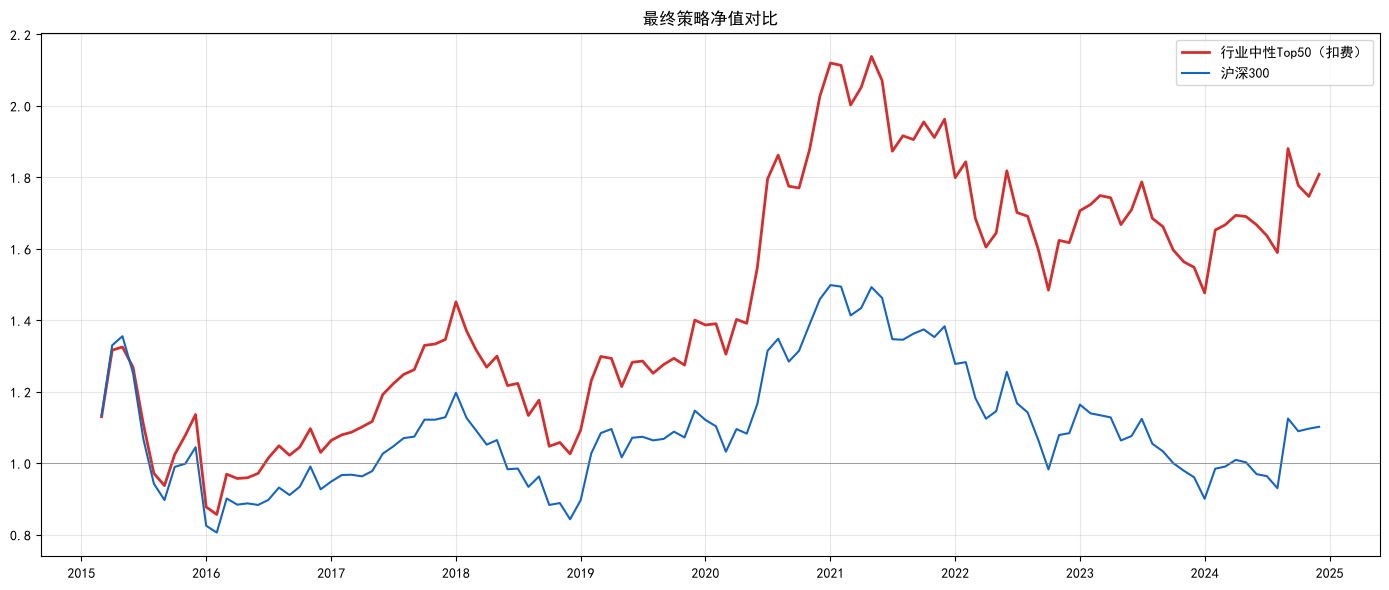

In [23]:
# ===== Selection rule: among candidates meeting IR >= 0.9, pick the one with the highest annualized excess return =====
cand = neutral_df[neutral_df['ir'] >= 0.9]
if len(cand) > 0:
    best_n = int(cand['ann_excess'].idxmax())
else:
    best_n = int(neutral_df['ir'].idxmax())   # fall back if none meet the threshold

print(f"OK Final industry-neutral N = {best_n}")
print(neutral_df.loc[best_n].round(3))

# ===== Final strategy NAV vs. CSI 300 =====
p = net_store[best_n].copy()
p.index = p.index + pd.DateOffset(months=1)
common = p.index.intersection(benchmark_ret.index)
p, b = p.loc[common], benchmark_ret.loc[common]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(p.index, (1+p).cumprod(), label=f'Industry-Neutral Top{best_n} (net of costs)', linewidth=2, color='#D32F2F')
ax.plot(b.index, (1+b).cumprod(), label='CSI 300', linewidth=1.5, color='#1565C0')
ax.axhline(1, color='gray', linewidth=0.5)
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Final Strategy NAV Comparison')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/final_strategy.png", dpi=150)
plt.show()